<a href="https://colab.research.google.com/github/Saifullah785/machine-learning-engineer-roadmap/blob/main/Lecture_06_instance_vs_Model_based_learning/Day_06_instance_vs_Model_based_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔥 Unraveling the Machine's Mind: Does Your AI Remember or Generalize? (Instance-Based vs Model-Based Learning)

---

Imagine you're trying to recommend a movie to a friend. Do you:

1.  **Recall every single movie they've ever liked** and find one that's super similar to those? (Like remembering a specific case)
2.  **Understand their overall taste** – maybe they like action-comedies with strong female leads – and then suggest a movie that fits this general pattern, even if they haven't seen an exact match before? (Like learning a general rule)

This simple dilemma perfectly captures the heart of how Machine Learning algorithms learn. Do they *remember* specific instances, or do they *generalize* from patterns? This notebook will demystify these two fundamental approaches: **Instance-Based Learning** and **Model-Based Learning**. By the end, you'll not only understand *how* models learn, but also *why* they sometimes choose to remember and sometimes to generalize.

Let's dive in and unlock the secrets of machine intelligence!

**Notebook Goal:** To build a strong intuition for Instance-Based and Model-Based learning, reinforced by practical code examples and clear visualizations, making you feel: "Now I deeply understand HOW models actually learn."

# 📖 Story Setup: Memory vs. Understanding

---

Think about how humans learn. When you were a child, you might have learned what a "dog" is by being shown many examples: "That's a dog," "No, that's a cat," "Yes, that's also a dog." You built up a mental library of specific dog instances.

As you grew older, you started to understand the *concept* of a dog: it's a four-legged animal, often barks, has fur, etc. You could then identify a new dog you'd never seen before, even if it looked very different from your past examples, because you understood the *general rules* of what makes a dog a dog.

Machines, just like us, learn in two fundamentally different ways that mirror this human experience:

*   **Remembering Examples (Instance-Based Learning):** They keep all the past data and compare new situations to those stored memories.
*   **Learning Concepts (Model-Based Learning):** They build a general rule or formula from the data, then discard the specifics and use that rule.

Let's explore each approach with real-world analogies and hands-on code!

# 🧠 What is Instance-Based Learning? – The "Remember and Refer" Approach

---

### 📌 Definition:

**Instance-Based Learning** (also known as Memory-Based Learning or Lazy Learning) is like a student who keeps all their old homework and test solutions. When faced with a new problem, they *don't try to derive a general formula*. Instead, they flip through their old assignments, find the problems that are *most similar* to the new one, and then use the solution from those similar cases to solve the current problem.

It works by:

*   **Memorizing all training data:** It stores every single example it has seen.
*   **No explicit model during training:** It doesn't create a formula or a set of rules until prediction time.
*   **Uses similarity (distance):** When a new data point arrives, it finds the 'closest' or 'most similar' instances from its memory and makes a decision based on those neighbors.

✅ **Analogy:** A doctor diagnosing a rare disease by recalling past patient cases with very similar symptoms, rather than relying on a general textbook definition.

### 🔎 Real-Life Examples:

*   **Movie Recommendation Systems:** "People who liked *Movie A* and *Movie B* also liked *Movie C*." (Finding similar users or similar items to recommend)
*   **Customer Support:** When you call with an issue, the system might quickly pull up records of customers who had very similar problems and what solutions worked for them.
*   **Fraud Detection:** Identifying a transaction as fraudulent because it looks very similar to previous known fraudulent transactions.

# 💻 Practical Example: K-Nearest Neighbors (KNN)

Let's use the classic Iris dataset to see Instance-Based Learning in action. KNN is a perfect example of this. It classifies a new data point based on the majority class of its 'k' nearest neighbors in the training data.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features
y = iris.target # Target (species)

# For simplicity and visualization, let's use only two features: sepal length and petal length
# This makes it easier to plot decision boundaries later
X_vis = X[:, [0, 2]] # Sepal Length (index 0) and Petal Length (index 2)

# Split data into training and testing sets
X_train_ib, X_test_ib, y_train_ib, y_test_ib = train_test_split(X_vis, y, test_size=0.3, random_state=42, stratify=y)

print("--- Iris Dataset Snippet ---")
# Fixed: Select feature names by creating a new list with the desired indices
print(pd.DataFrame(X_vis, columns=[iris.feature_names[0], iris.feature_names[2]]).head())
print(f"\nTraining data shape: {X_train_ib.shape}")
print(f"Testing data shape: {X_test_ib.shape}")

# Initialize and train the KNN model
k = 3 # Number of neighbors to consider
knn_model = KNeighborsClassifier(n_neighbors=k)

# Training (KNN just 'remembers' the data)
knn_model.fit(X_train_ib, y_train_ib)
print(f"\nKNN Model trained with k={k}. It stores {len(X_train_ib)} instances.")

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test_ib)

# Evaluate the model
accuracy_knn = accuracy_score(y_test_ib, y_pred_knn)
print(f"\nKNN Model Accuracy on Test Set: {accuracy_knn:.2f}")

# Let's see a few predictions vs actuals
print("\n--- Sample KNN Predictions ---")
for i in range(5):
    print(f"Actual: {iris.target_names[y_test_ib[i]]}, Predicted: {iris.target_names[y_pred_knn[i]]}")

# How similarity works in KNN:
print("\n--- How KNN 'decides' ---")
# Let's pick one test point and see its neighbors
sample_point = X_test_ib[0] # The first test point
distances, indices = knn_model.kneighbors([sample_point])

print(f"Sample Test Point: {sample_point} (Actual: {iris.target_names[y_test_ib[0]]})")
print(f"Its {k} nearest neighbors in training data:")
for i in range(k):
    neighbor_idx = indices[0][i]
    print(f"  Neighbor {i+1}: Features {X_train_ib[neighbor_idx]}, Class {iris.target_names[y_train_ib[neighbor_idx]]}, Distance: {distances[0][i]:.2f}")
print(f"KNN predicts based on these neighbors. In this case, the majority class among these neighbors is {iris.target_names[y_pred_knn[0]]}.")

--- Iris Dataset Snippet ---
   sepal length (cm)  petal length (cm)
0                5.1                1.4
1                4.9                1.4
2                4.7                1.3
3                4.6                1.5
4                5.0                1.4

Training data shape: (105, 2)
Testing data shape: (45, 2)

KNN Model trained with k=3. It stores 105 instances.

KNN Model Accuracy on Test Set: 0.96

--- Sample KNN Predictions ---
Actual: virginica, Predicted: virginica
Actual: versicolor, Predicted: versicolor
Actual: virginica, Predicted: virginica
Actual: versicolor, Predicted: versicolor
Actual: virginica, Predicted: virginica

--- How KNN 'decides' ---
Sample Test Point: [7.3 6.3] (Actual: virginica)
Its 3 nearest neighbors in training data:
  Neighbor 1: Features [7.2 6.1], Class virginica, Distance: 0.22
  Neighbor 2: Features [7.4 6.1], Class virginica, Distance: 0.22
  Neighbor 3: Features [7.2 6. ], Class virginica, Distance: 0.32
KNN predicts based on these 

### 💡 Expert Insight:

Notice how KNN doesn't learn a *function* like `y = mx + b`. Instead, during `fit()`, it simply stores the data. The 'learning' (finding neighbors, calculating distances) only happens when you ask it to make a prediction. This is why it's called "Lazy Learning"!

# ⚙️ What is Model-Based Learning? – The "Learn and Generalize" Approach

---

### 📌 Definition:

**Model-Based Learning** (also known as Eager Learning) is like a student who, after seeing many examples, **figures out the underlying formula or principle**. Once they have this formula, they can throw away all the specific examples. When a new problem comes, they just plug the new numbers into their learned formula to get an answer.

It works by:

*   **Building an explicit model:** It creates a mathematical function, a decision tree, or a set of parameters during training.
*   **Generalizing patterns:** It identifies relationships and patterns within the data.
*   **Forgetting training data:** After training, the model itself is sufficient for predictions; the raw training data is no longer needed.

✅ **Analogy:** A physicist observing many falling objects and then deriving Newton's Law of Universal Gravitation. Once the law is known, they can predict the behavior of any new falling object without needing to recall specific past observations.

### 🔎 Real-Life Examples:

*   **House Price Prediction:** Using features like size, number of bedrooms, and location to build a formula that estimates the price of *any* house.
*   **Credit Scoring:** A model learns the likelihood of a person repaying a loan based on their financial history and demographic data, resulting in a credit score formula.
*   **Spam Detection:** A model learns specific words, phrases, and sender characteristics that distinguish spam from legitimate emails.

# 💻 Practical Example: Logistic Regression

Logistic Regression, despite its name, is a classification algorithm. It learns a *linear boundary* that separates different classes. It's a classic example of Model-Based Learning, as it builds an explicit model (a set of coefficients) during training.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
# We'll use a 'multinomial' solver as we have more than two classes
log_reg_model = LogisticRegression(random_state=42, solver='lbfgs', multi_class='multinomial', max_iter=200)

# Training (Logistic Regression learns explicit parameters)
log_reg_model.fit(X_train_ib, y_train_ib)
print("\nLogistic Regression Model trained. It has learned an explicit model (coefficients).")

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test_ib)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test_ib, y_pred_log_reg)
print(f"\nLogistic Regression Model Accuracy on Test Set: {accuracy_log_reg:.2f}")

# Let's see a few predictions vs actuals
print("\n--- Sample Logistic Regression Predictions ---")
for i in range(5):
    print(f"Actual: {iris.target_names[y_test_ib[i]]}, Predicted: {iris.target_names[y_pred_log_reg[i]]}")

# Explanation of learned parameters:
print("\n--- Learned Parameters (Coefficients) of Logistic Regression ---")
# For multi-class classification, there are coefficients for each class for each feature
# We'll just show the shape and first few values to illustrate they exist
print(f"Coefficients (weights) shape: {log_reg_model.coef_.shape}")
print(f"Intercepts shape: {log_reg_model.intercept_.shape}")
print("First few coefficients for each class (features 0 and 2):")
for i, class_name in enumerate(iris.target_names):
    print(f"  Class {class_name}: {log_reg_model.coef_[i, :].round(2)}")
print("These coefficients define the linear decision boundaries the model has learned.")


Logistic Regression Model trained. It has learned an explicit model (coefficients).

Logistic Regression Model Accuracy on Test Set: 0.93

--- Sample Logistic Regression Predictions ---
Actual: virginica, Predicted: virginica
Actual: versicolor, Predicted: versicolor
Actual: virginica, Predicted: virginica
Actual: versicolor, Predicted: versicolor
Actual: virginica, Predicted: virginica

--- Learned Parameters (Coefficients) of Logistic Regression ---
Coefficients (weights) shape: (3, 2)
Intercepts shape: (3,)
First few coefficients for each class (features 0 and 2):
  Class setosa: [-0.46 -2.74]
  Class versicolor: [ 0.43 -0.34]
  Class virginica: [0.03 3.08]
These coefficients define the linear decision boundaries the model has learned.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### 💡 Expert Insight:

Unlike KNN, after `log_reg_model.fit()`, you could theoretically discard `X_train_ib` and `y_train_ib`. The `log_reg_model` object itself contains all the learned knowledge (the `coef_` and `intercept_` values) needed to make future predictions. This is the essence of "eager learning"!

# 🔺 Instance-Based vs. Model-Based: A Core Comparison

---

Now that we've seen both in action, let's put them side-by-side to highlight their key differences. This table is your quick reference guide!

| Feature             | Instance-Based Learning               | Model-Based Learning                     |
| :------------------ | :------------------------------------ | :--------------------------------------- |
| **Learning Style**  | Memorization (lazy)                   | Generalization (eager)                   |
| **Training Phase**  | Stores data, minimal computation      | Builds explicit model (e.g., formula)    |
| **Prediction Phase**| Compares new data to *all* stored data| Applies learned model/formula            |
| **Speed**           | Slow prediction (on large datasets)   | Fast prediction (after training)         |
| **Memory Usage**    | High (stores all training data)       | Low (stores only model parameters)       |
| **Interpretability**| Can be local (why *this* neighbor?)   | Often global (coefficients, rules)       |
| **Complexity**      | Handles complex decision boundaries   | Can oversimplify complex patterns        |
| **Examples**        | K-Nearest Neighbors (KNN), Case-Based Reasoning | Linear/Logistic Regression, Decision Trees, Neural Networks |


# ⚙️ Hands-On Comparison: KNN vs. Logistic Regression on the Same Data

---

Let's directly compare our two models on the same dataset and test set to truly understand their performance characteristics and how their underlying learning philosophies manifest in results.

We'll use the accuracy we already calculated and then visualize their decision boundaries to see the difference clearly.

In [ ]:
# We already have X_train_ib, X_test_ib, y_train_ib, y_test_ib
# And models: knn_model, log_reg_model
# And accuracies: accuracy_knn, accuracy_log_reg

print(f"--- Comparative Performance on Iris Dataset ---")
print(f"K-Nearest Neighbors (k=3) Accuracy: {accuracy_knn:.2f}")
print(f"Logistic Regression Accuracy:     {accuracy_log_reg:.2f}")

print("\n--- Analysis of Differences ---")
if accuracy_knn > accuracy_log_reg:
    print("In this specific case, KNN performed slightly better. This often happens when decision boundaries are complex or highly non-linear, as KNN can adapt locally.")
elif accuracy_log_reg > accuracy_knn:
    print("In this specific case, Logistic Regression performed slightly better. This might indicate that the classes are linearly separable or close to it, and a simpler, generalized model is sufficient.")
else:
    print("Both models performed equally well on this dataset.")

print("\nKNN's predictions are a direct consequence of its closest neighbors. If a new point is near a cluster of 'versicolor' training points, it will be classified as 'versicolor', regardless of the overall global pattern.")
print("Logistic Regression's predictions come from its learned linear decision boundaries. It tries to draw straight lines to separate the classes, and any point on one side of the line belongs to one class, and on the other, to another.")
print("This difference in approach will be even clearer in the visualizations!")

--- Comparative Performance on Iris Dataset ---
K-Nearest Neighbors (k=3) Accuracy: 0.96
Logistic Regression Accuracy:     0.93

--- Analysis of Differences ---
In this specific case, KNN performed slightly better. This often happens when decision boundaries are complex or highly non-linear, as KNN can adapt locally.

KNN's predictions are a direct consequence of its closest neighbors. If a new point is near a cluster of 'versicolor' training points, it will be classified as 'versicolor', regardless of the overall global pattern.
Logistic Regression's predictions come from its learned linear decision boundaries. It tries to draw straight lines to separate the classes, and any point on one side of the line belongs to one class, and on the other, to another.
This difference in approach will be even clearer in the visualizations!


# 📊 Visualization: Seeing Decision Boundaries Come to Life

---

This is where it gets really insightful! By visualizing the decision boundaries, we can literally *see* how Instance-Based and Model-Based learning approaches problems differently.

*   **KNN:** Expect jagged, irregular boundaries that hug the training data points. It adapts *locally*.
*   **Logistic Regression:** Expect straight lines or smooth curves (for more complex model-based methods). It forms *global* patterns.

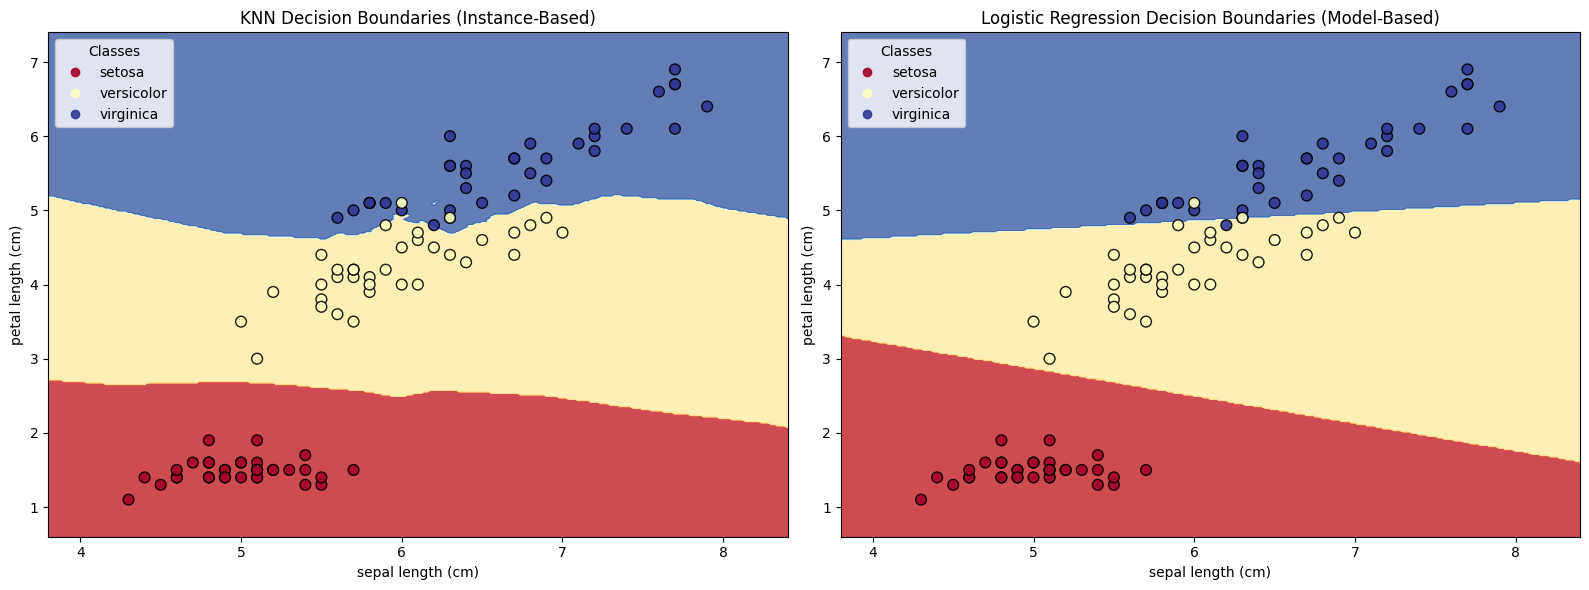

In [ ]:
# Function to plot decision boundaries
def plot_decision_boundaries(X, y, model, title, ax):
    # Define ranges for the plot
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # Create a meshgrid to plot the decision surface
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Predict class for each point in the meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundaries
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

    # Plot the training points
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='k', s=60, alpha=0.9)

    ax.set_title(title)
    ax.set_xlabel(iris.feature_names[0]) # Sepal Length
    ax.set_ylabel(iris.feature_names[2]) # Petal Length

    # Create a legend
    handles, labels = scatter.legend_elements()
    labels_map = {0: iris.target_names[0], 1: iris.target_names[1], 2: iris.target_names[2]}
    legend_labels = [labels_map[int(label.split('{')[-1].split('}')[0])] for label in labels]
    ax.legend(handles, legend_labels, title="Classes")

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot for KNN
plot_decision_boundaries(X_train_ib, y_train_ib, knn_model, 'KNN Decision Boundaries (Instance-Based)', ax1)

# Plot for Logistic Regression
plot_decision_boundaries(X_train_ib, y_train_ib, log_reg_model, 'Logistic Regression Decision Boundaries (Model-Based)', ax2)

plt.tight_layout()
plt.show()

## 🤯 What did we see?

*   **KNN:** Notice how the decision boundaries are irregular and follow the clusters of the individual data points very closely. It's almost as if it's saying, "If you're near these particular red dots, you're red!"
*   **Logistic Regression:** Its boundaries are smooth and straight lines, trying to find the best linear separation across the *entire* feature space. It's saying, "If you're on this side of the line, you're red, regardless of a single red dot on the other side."

This visualization vividly demonstrates the core difference: **local adaptation based on memory** for instance-based, versus **global generalization through a learned function** for model-based.

# 🌍 Real-Life Applications: Where Do They Shine?

---

Understanding these two learning paradigms helps us choose the right tool for the job. Each has its domain where it truly excels.

### Instance-Based Learning excels when:

*   **Recommendation Systems:** Think of Netflix suggesting movies. It's often finding users with *similar viewing histories* or movies with *similar attributes* to what you've enjoyed. The "model" is essentially the vast database of user preferences and item characteristics.
*   **Anomaly Detection:** If a new network packet looks significantly different from *all previously seen normal packets* but very similar to known malicious ones, an instance-based approach can quickly flag it as an anomaly. This is about spotting unusual *instances*.
*   **Personalized Medicine:** Finding treatment plans by matching a patient's unique profile (symptoms, genetics, medical history) to *highly similar past cases* where treatments were effective.

### Model-Based Learning excels when:

*   **Forecasting Stock Prices or Sales:** Here, we're looking for underlying trends and patterns over time that can be generalized into a predictive formula. We want to predict future values based on past *relationships*, not just past individual stock prices.
*   **Medical Diagnosis (from generalized rules):** A model learns the *general features* that indicate a disease (e.g., specific blood test ranges, combinations of symptoms) and can then apply this general knowledge to new patients, even if their specific case isn't an exact match to any training example.
*   **Spam Filtering:** The goal is to develop a *general rule set* (e.g., certain keywords, sender domains, email structure) that defines what constitutes spam, allowing the system to categorize new, unseen emails efficiently.

## ⚠️ Limitations & Trade-offs: No Free Lunch!

---

Just like there's no perfect tool for every job, neither instance-based nor model-based learning is universally superior. Understanding their limitations helps us make informed decisions.

### Instance-Based Learning:

*   **Slow Predictions (Scalability Issue):** For every new prediction, it has to compute distances to *all* (or many) training examples. As your dataset grows to millions or billions of instances, this can become prohibitively slow.
*   **High Memory Usage:** It needs to store the entire training dataset in memory (or at least readily accessible), which can be massive for large datasets.
*   **Sensitive to Irrelevant Features:** If your data has many features that don't contribute to similarity, they can "confuse" the distance calculations, making the model less effective.
*   **Curse of Dimensionality:** In very high-dimensional spaces, the concept of "distance" becomes less meaningful, and all points tend to appear equidistant, making finding true nearest neighbors difficult.

### Model-Based Learning:

*   **Needs Training Time:** Building the model can be computationally intensive and time-consuming, especially for complex models (e.g., deep neural networks).
*   **May Oversimplify Complex Patterns:** If the true underlying relationship in the data is very complex and the chosen model is too simple (e.g., trying to fit a straight line to a highly curved pattern), it might fail to capture the nuances.
*   **Assumptions:** Many model-based algorithms make assumptions about the data (e.g., linearity in Logistic Regression, Gaussian distributions). If these assumptions are violated, the model's performance can suffer.
*   **Interpretability Trade-off:** While some models (like linear regression or simple decision trees) are highly interpretable, others (like deep neural networks) can be black boxes, making it hard to understand *why* they make certain predictions.

# 🧪 Mini Project: A Complete End-to-End Comparison

---

Let's consolidate our learning with a small, complete project. We'll reuse our Iris dataset, but this time, we'll encapsulate the steps clearly and perform a side-by-side comparison from data loading to evaluation.

This will reinforce the entire workflow for both Instance-Based and Model-Based approaches.

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Important for distance-based models like KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print("--- Mini Project: Instance-Based vs. Model-Based Comparison ---")

# 1. Data Loading
print("\n1. Loading Data...")
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Display basic info
df_full = pd.DataFrame(X, columns=feature_names)
df_full['species'] = pd.Categorical.from_codes(y, target_names)
print("Dataset loaded. First 5 rows:")
display(df_full.head())
print(f"Dataset shape: {X.shape}")

# 2. Data Preprocessing
# Split the data into training and testing sets
# Using a larger test size here to ensure a good split for comparison
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"\n2. Data split into training ({X_train.shape[0]} samples) and testing ({X_test.shape[0]} samples).")

# Feature Scaling is CRUCIAL for KNN (distance-based) and often beneficial for Logistic Regression
# Scale features to have zero mean and unit variance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features scaled (StandardScaler applied).")

# 3. Instance-Based Model: K-Nearest Neighbors (KNN)
print("\n3. Training K-Nearest Neighbors (Instance-Based Model)...")
knn_final_model = KNeighborsClassifier(n_neighbors=5) # Using 5 neighbors
knn_final_model.fit(X_train_scaled, y_train) # Training involves storing scaled data

y_pred_knn_final = knn_final_model.predict(X_test_scaled)
accuracy_knn_final = accuracy_score(y_test, y_pred_knn_final)

print(f"KNN Model Accuracy: {accuracy_knn_final:.4f}")
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn_final, target_names=target_names))

# 4. Model-Based Algorithm: Logistic Regression
print("\n4. Training Logistic Regression (Model-Based Model)...")
log_reg_final_model = LogisticRegression(random_state=42, solver='lbfgs', multi_class='multinomial', max_iter=200)
log_reg_final_model.fit(X_train_scaled, y_train) # Training involves learning coefficients

y_pred_log_reg_final = log_reg_final_model.predict(X_test_scaled)
accuracy_log_reg_final = accuracy_score(y_test, y_pred_log_reg_final)

print(f"Logistic Regression Model Accuracy: {accuracy_log_reg_final:.4f}")
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log_reg_final, target_names=target_names))

# 5. Compare Results
print("\n5. Final Comparison:")
print(f"  KNN Final Accuracy: {accuracy_knn_final:.4f}")
print(f"  Logistic Regression Final Accuracy: {accuracy_log_reg_final:.4f}")

if accuracy_knn_final > accuracy_log_reg_final:
    print("\nIn this complete run, KNN performed slightly better. This indicates that for the Iris dataset, local patterns might be more distinguishing or the dataset has somewhat complex boundaries that KNN can capture well.")
elif accuracy_log_reg_final > accuracy_knn_final:
    print("\nIn this complete run, Logistic Regression performed slightly better. This suggests that the classes in the Iris dataset are quite linearly separable, making a generalized model highly effective.")
else:
    print("\nBoth models performed almost identically in this scenario.")

print("\nThis mini-project demonstrates that both methods can achieve good results, but their underlying mechanisms for reaching those results are fundamentally different – one remembers instances, the other learns a general rule.")

--- Mini Project: Instance-Based vs. Model-Based Comparison ---

1. Loading Data...
Dataset loaded. First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Dataset shape: (150, 4)

2. Data split into training (105 samples) and testing (45 samples).
Features scaled (StandardScaler applied).

3. Training K-Nearest Neighbors (Instance-Based Model)...
KNN Model Accuracy: 0.9111
KNN Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45


4. Training Logistic Regression (Model-Based Model)...
Logistic Regression Model Accuracy: 0.9111
Logistic Regression Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accurac

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


# 🧠 Key Takeaways

---

Here's what you should carry forward from this lecture:

*   **Two Core Learning Philosophies:** Machines learn either by **remembering specific examples (Instance-Based)** or by **generalizing patterns into a model (Model-Based)**.
*   **Instance-Based (Lazy Learning):** Stores all data, makes decisions based on similarity to neighbors. Think `K-Nearest Neighbors`.
    *   ✅ Adapts locally, no training time.
    *   ❌ Slow prediction, high memory, sensitive to irrelevant features.
*   **Model-Based (Eager Learning):** Learns a general formula/function from data, then forgets the specifics. Think `Logistic Regression`, `Decision Trees`, `Neural Networks`.
    *   ✅ Fast prediction, low memory (after training), generalizes well.
    *   ❌ Needs training time, might oversimplify, relies on assumptions.
*   **Visual Distinction:** Instance-based models have irregular, local decision boundaries. Model-based models have smoother, global decision boundaries.
*   **Choosing the Right Approach:** Depends on dataset size, complexity of decision boundaries, and performance requirements.

You now have a deep understanding of *how* models approach learning, whether by diligent recall or insightful generalization!

## 🔮 Next Lecture Hook: Beyond Learning Methods – The Perils of Bad Fit!

---

We've uncovered the two main ways machines learn: by remembering and by generalizing. But what happens if a machine remembers *too much* or generalizes *too little*? Or perhaps it generalizes *too broadly*?

Consider this:

*   **What if our model is like a student who memorizes every single answer, but can't solve a slightly different problem?** (The instance-based approach gone wrong!)
*   **What if our model is like a student who only learns a very simple rule, ignoring all the details, and makes many mistakes on complex problems?** (The model-based approach being too simplistic!)

These scenarios lead us to a crucial concept in Machine Learning, one that can make or break a model's real-world performance.

👉 **Next Lecture: Overfitting vs. Underfitting – The Goldilocks Zone of Model Learning!**

We'll explore how models can be *too complex* or *too simple*, and how to find that 'just right' balance for optimal performance.

# 📌 Conclusion: Your Journey into Machine Learning Deepens!

---

Congratulations! You've just taken a monumental step in understanding the foundational concepts of Machine Learning. You've looked beyond the buzzwords and grasped the core mechanics that drive AI decisions.

From the meticulous memory of instance-based models to the elegant generalization of model-based algorithms, you now appreciate the diverse strategies machines employ to learn from data. This isn't just theory; it's the bedrock upon which all advanced ML techniques are built.

Keep exploring, keep questioning, and keep building! The world of machine learning is vast and exciting, and you're now equipped with an even stronger intuition to navigate its depths. Go forth and make machines learn wisely!

## Resources

*   [Scikit-learn Documentation: K-Nearest Neighbors](https://scikit-learn.org/stable/modules/neighbors.html)
*   [Scikit-learn Documentation: Logistic Regression](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)
*   [Géron, Aurélien. Hands-on Machine Learning with Scikit-Learn, Keras, and TensorFlow. O'Reilly Media, 2019.](https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/)
